# 08 — Modelo de Imágenes Mejorado

Flujo: embeddings se extraen **una sola vez**, Optuna optimiza n_pca + LightGBM.

Backbones disponibles: `efficientnet_b3` | `resnet50` | `convnext_tiny` | `clip_vitb32`

## 1. Instalación e imports

In [1]:
#  Clonar repo
import os
if not os.path.exists('/content/participant_Labo2_Grupo10'):
    !git clone https://github.com/micapolchi/participant_Labo2_Grupo10.git



import sys
sys.path.insert(0, '/content/participant_Labo2_Grupo10')

Cloning into 'participant_Labo2_Grupo10'...
remote: Enumerating objects: 19253, done.
remote: Counting objects: 100% (49/49), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 19253 (delta 21), reused 32 (delta 8), pack-reused 19204 (from 1)
Receiving objects: 100% (19253/19253), 786.20 MiB | 39.51 MiB/s, done.
Resolving deltas: 100% (24/24), done.
Updating files: 100% (19275/19275), done.


In [2]:
import os
os.chdir("/content/participant_Labo2_Grupo10")

In [3]:
!pip install optuna --quiet
!pip install git+https://github.com/openai/CLIP.git --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 14.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.3 MB/s eta 0:00:00


In [4]:
import os
import pandas as pd
import numpy as np
import lightgbm as lgb
import optuna
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
import torch
import torchvision.models as models
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from PIL import Image

optuna.logging.set_verbosity(optuna.logging.WARNING)

if not os.path.exists('data/tabular/train_processed.csv'):
    os.chdir('..')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


## 2. Configuración

In [5]:
BACKBONE   = 'clip_vitb32'  # opciones: efficientnet_b3 | resnet50 | convnext_tiny | clip_vitb32
MAX_IMGS   = 6
BATCH_SIZE = 64
N_FOLDS    = 5
N_TRIALS   = 30
SUBMISSION = 'submissions/test_image_08.csv'

TARGET    = 'log_price'
PRICE_COL = 'lastSoldPrice_hpi_adjusted'

os.makedirs('submissions', exist_ok=True)

## 3. Carga de datos

In [6]:
train_meta = pd.read_csv('data/train_photo_metadata.csv')
test_meta  = pd.read_csv('data/test_photo_metadata.csv')
train_tab  = pd.read_csv('data/tabular/train_processed.csv')
test_tab   = pd.read_csv('data/tabular/test_processed.csv')

if MAX_IMGS:
    train_meta = train_meta[train_meta['image_index'] < MAX_IMGS].copy()
    test_meta  = test_meta[test_meta['image_index']  < MAX_IMGS].copy()

print(f'Train fotos: {len(train_meta):,}  |  Test fotos: {len(test_meta):,}')
print(f'Train props: {train_meta["zpid"].nunique():,}  |  Test props: {test_meta["zpid"].nunique():,}')

Train fotos: 36,103  |  Test fotos: 15,593
Train props: 10,666  |  Test props: 4,590


## 4. Backbone y dataset

Cada backbone devuelve su propio `transform`. CLIP usa su preprocesamiento nativo.

In [7]:
class PropertyImageDataset(Dataset):
    def __init__(self, paths, transform):
        self.paths = paths
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        try:
            img = Image.open(self.paths[idx]).convert('RGB')
            return self.transform(img)
        except Exception:
            return torch.zeros(3, 224, 224)


def build_backbone(name):
    """Devuelve (modelo, transform). Cada backbone gestiona su propio preprocesamiento."""
    imagenet_transform = T.Compose([
        T.Resize(256),
        T.CenterCrop(224),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    if name == 'clip_vitb32':
        import clip
        clip_model, clip_preprocess = clip.load('ViT-B/32', device=DEVICE)
        clip_model.eval()

        class CLIPWrapper(torch.nn.Module):
            def __init__(self, m):
                super().__init__()
                self.m = m
            def forward(self, x):
                return self.m.encode_image(x).float()

        return CLIPWrapper(clip_model), clip_preprocess

    if name == 'efficientnet_b3':
        m = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)
        m.classifier = torch.nn.Identity()
    elif name == 'convnext_tiny':
        m = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
        m.classifier = torch.nn.Identity()
    elif name == 'resnet50':
        m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        m = torch.nn.Sequential(*list(m.children())[:-1], torch.nn.Flatten())
    else:
        raise ValueError(f'Backbone desconocido: {name}')

    return m.to(DEVICE).eval(), imagenet_transform


backbone, transform = build_backbone(BACKBONE)
print(f'Backbone: {BACKBONE} listo en {DEVICE}')

100%|███████████████████████████████████████| 338M/338M [00:03<00:00, 99.2MiB/s]


Backbone: clip_vitb32 listo en cuda


## 5. Extracción de embeddings (una sola vez)

In [8]:
def extract_mean_embeddings(meta_df):
    paths = meta_df['image_path'].tolist()
    zpids = meta_df['zpid'].tolist()
    ds = PropertyImageDataset(paths, transform)
    dl = DataLoader(ds, batch_size=BATCH_SIZE, num_workers=0,
                    pin_memory=(DEVICE.type == 'cuda'))
    all_embs = []
    with torch.no_grad():
        for batch in dl:
            embs = backbone(batch.to(DEVICE))
            all_embs.append(embs.cpu().numpy())
    emb_matrix = np.vstack(all_embs)
    emb_df = pd.DataFrame(emb_matrix)
    emb_df['zpid'] = zpids
    return emb_df.groupby('zpid').mean().reset_index()


print('Extrayendo embeddings de train...')
train_embs_df = extract_mean_embeddings(train_meta)
print(f'  {len(train_embs_df)} propiedades, {train_embs_df.shape[1]-1} dims')

print('Extrayendo embeddings de test...')
test_embs_df = extract_mean_embeddings(test_meta)
print(f'  {len(test_embs_df)} propiedades, {test_embs_df.shape[1]-1} dims')

EMB_COLS = [c for c in train_embs_df.columns if c != 'zpid']

Extrayendo embeddings de train...
  10666 propiedades, 512 dims
Extrayendo embeddings de test...
  4590 propiedades, 512 dims


## 6. Optuna — búsqueda de hiperparámetros

Busca sobre `n_pca` y todos los hiperparámetros de LightGBM.
Los embeddings ya están en memoria; cada trial solo re-corre PCA + CV (rápido).

In [9]:
train_base = train_tab[['zpid', TARGET, PRICE_COL]]


def objective(trial):
    n_pca = trial.suggest_int('n_pca', 32, 256, step=32)

    params = dict(
        n_estimators      = 2000,
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        num_leaves        = trial.suggest_int('num_leaves', 31, 255),
        min_child_samples = trial.suggest_int('min_child_samples', 10, 60),
        feature_fraction  = trial.suggest_float('feature_fraction', 0.5, 1.0),
        bagging_fraction  = trial.suggest_float('bagging_fraction', 0.5, 1.0),
        bagging_freq      = 1,
        reg_alpha         = trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        random_state      = 42,
        verbosity         = -1,
    )

    pca_t = PCA(n_components=n_pca, random_state=42)
    tr_pca = pca_t.fit_transform(train_embs_df[EMB_COLS].values)

    pca_cols = [f'pca_{i}' for i in range(n_pca)]
    tr_pca_df = pd.DataFrame(tr_pca, columns=pca_cols)
    tr_pca_df['zpid'] = train_embs_df['zpid'].values

    t_data = train_base.merge(tr_pca_df, on='zpid', how='inner')

    kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    mapes = []

    for tr_idx, val_idx in kf.split(t_data):
        tr_df  = t_data.iloc[tr_idx]
        val_df = t_data.iloc[val_idx]

        m = lgb.LGBMRegressor(**params)
        m.fit(
            tr_df[pca_cols], tr_df[TARGET],
            eval_set=[(val_df[pca_cols], val_df[TARGET])],
            eval_metric='mae',
            callbacks=[
                lgb.early_stopping(stopping_rounds=50, verbose=False),
                lgb.log_evaluation(period=-1),
            ],
        )

        val_pred  = m.predict(val_df[pca_cols])
        val_price = val_df[PRICE_COL].values
        mapes.append(np.mean(np.abs((val_price - np.expm1(val_pred)) / val_price)) * 100)

    return np.mean(mapes)


study = optuna.create_study(direction='minimize', study_name='img_lgbm')
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f'\nMejor MAPE OOF: {study.best_value:.2f}%')
print('Mejores parámetros:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

  0%|          | 0/30 [00:00<?, ?it/s]


Mejor MAPE OOF: 61.59%
Mejores parámetros:
  n_pca: 64
  learning_rate: 0.017881798950942534
  num_leaves: 125
  min_child_samples: 11
  feature_fraction: 0.7635079792479648
  bagging_fraction: 0.558256319406633
  reg_alpha: 0.04572478836177592
  reg_lambda: 0.0011720021722205832


## 7. Modelo final con mejores parámetros

In [10]:
best  = study.best_params
N_PCA = best['n_pca']

BEST_PARAMS = dict(
    n_estimators      = 2000,
    learning_rate     = best['learning_rate'],
    num_leaves        = best['num_leaves'],
    min_child_samples = best['min_child_samples'],
    feature_fraction  = best['feature_fraction'],
    bagging_fraction  = best['bagging_fraction'],
    bagging_freq      = 1,
    reg_alpha         = best['reg_alpha'],
    reg_lambda        = best['reg_lambda'],
    random_state      = 42,
    verbosity         = -1,
)

pca_final = PCA(n_components=N_PCA, random_state=42)
train_pca  = pca_final.fit_transform(train_embs_df[EMB_COLS].values)
test_pca   = pca_final.transform(test_embs_df[EMB_COLS].values)
print(f'PCA final: {len(EMB_COLS)} -> {N_PCA} dims  |  varianza: {pca_final.explained_variance_ratio_.sum():.2%}')

PCA_COLS = [f'pca_{i}' for i in range(N_PCA)]

train_pca_df = pd.DataFrame(train_pca, columns=PCA_COLS)
train_pca_df['zpid'] = train_embs_df['zpid'].values
test_pca_df  = pd.DataFrame(test_pca,  columns=PCA_COLS)
test_pca_df['zpid']  = test_embs_df['zpid'].values

train_data = train_tab[['zpid', TARGET, PRICE_COL]].merge(train_pca_df, on='zpid', how='inner')
test_data  = test_tab[['zpid']].merge(test_pca_df, on='zpid', how='left')

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
oof_pred_log   = np.zeros(len(train_data))
test_pred_logs = np.zeros((len(test_data), N_FOLDS))
feat_imps      = np.zeros(N_PCA)

print('=' * 60)
print(f'{"Fold":>5}  {"MAPE train":>10}  {"MAPE val":>10}  {"best iter":>10}')
print('=' * 60)

for fold, (tr_idx, val_idx) in enumerate(kf.split(train_data)):
    tr_df  = train_data.iloc[tr_idx]
    val_df = train_data.iloc[val_idx]
    model = lgb.LGBMRegressor(**BEST_PARAMS)
    model.fit(
        tr_df[PCA_COLS], tr_df[TARGET],
        eval_set=[(val_df[PCA_COLS], val_df[TARGET])],
        eval_metric='mae',
        callbacks=[
            lgb.early_stopping(stopping_rounds=60, verbose=False),
            lgb.log_evaluation(period=-1),
        ],
    )
    val_pred  = model.predict(val_df[PCA_COLS])
    oof_pred_log[val_idx] = val_pred
    val_price = val_df[PRICE_COL].values
    mape_val  = np.mean(np.abs((val_price - np.expm1(val_pred)) / val_price)) * 100
    tr_price  = tr_df[PRICE_COL].values
    mape_tr   = np.mean(np.abs((tr_price - np.expm1(model.predict(tr_df[PCA_COLS]))) / tr_price)) * 100
    print(f'  {fold+1:>3}  {mape_tr:>9.2f}%  {mape_val:>9.2f}%  {model.best_iteration_:>10}')
    test_pred_logs[:, fold] = model.predict(test_data[PCA_COLS].fillna(0))
    feat_imps += model.feature_importances_

PCA final: 512 -> 64 dims  |  varianza: 96.20%
 Fold  MAPE train    MAPE val   best iter
    1      54.59%      60.13%         134
    2      53.37%      60.44%         173
    3      49.06%      63.52%         382
    4      51.40%      62.85%         227
    5      49.99%      60.93%         364


## 8. Métricas OOF

In [11]:
oof_price  = np.expm1(oof_pred_log)
true_price = train_data[PRICE_COL].values
oof_mape   = np.mean(np.abs((true_price - oof_price) / true_price)) * 100
oof_mae    = mean_absolute_error(true_price, oof_price)
print('=' * 60)
print(f'OOF MAPE: {oof_mape:.2f}%')
print(f'OOF MAE:  ${oof_mae:,.0f}')
print(f'Mejor MAPE Optuna: {study.best_value:.2f}%')

OOF MAPE: 61.58%
OOF MAE:  $253,578
Mejor MAPE Optuna: 61.59%


## 9. Importancia de componentes PCA

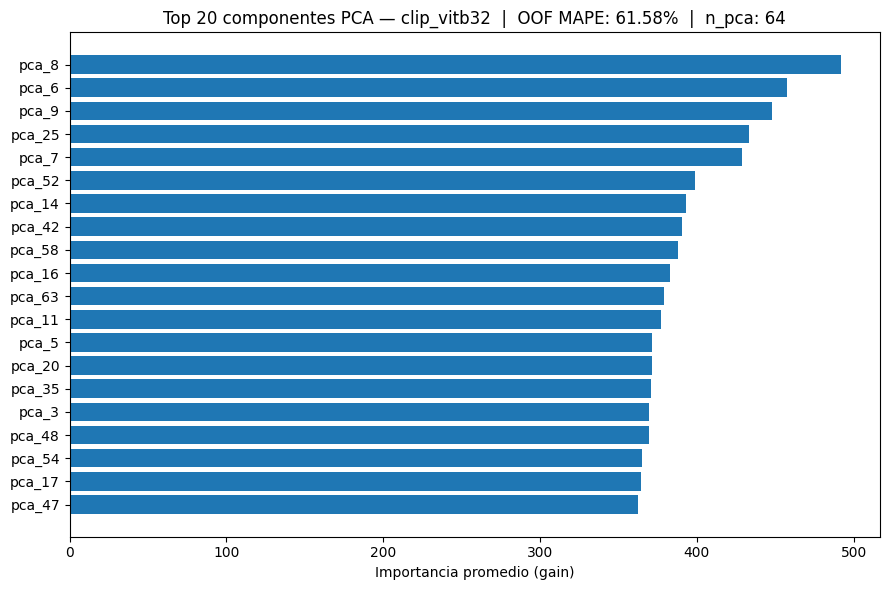

In [12]:
import matplotlib.pyplot as plt

fi_df = pd.DataFrame({
    'component':  PCA_COLS,
    'importance': feat_imps / N_FOLDS,
}).sort_values('importance', ascending=False)

top20 = fi_df.head(20)
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top20['component'][::-1], top20['importance'][::-1])
ax.set_xlabel('Importancia promedio (gain)')
ax.set_title(f'Top 20 componentes PCA — {BACKBONE}  |  OOF MAPE: {oof_mape:.2f}%  |  n_pca: {N_PCA}')
plt.tight_layout()
plt.show()

## 10. Submission

In [13]:
test_pred_price = np.expm1(test_pred_logs.mean(axis=1))
img_preds  = pd.DataFrame({'zpid': test_data['zpid'].values, 'predicted_price': test_pred_price})
submission = test_tab[['zpid']].merge(img_preds, on='zpid', how='left')
submission['predicted_price'].fillna(submission['predicted_price'].median(), inplace=True)
submission.to_csv(SUBMISSION, index=False)
print(f'Guardado {SUBMISSION} ({len(submission)} filas)')
submission.head()

Guardado submissions/test_image_08.csv (5038 filas)


/tmp/ipykernel_6710/3517463658.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  submission['predicted_price'].fillna(submission['predicted_price'].median(), inplace=True)


,zpid,predicted_price
0,1009018,450440.659292
1,1001436,471882.344211
2,1010988,424365.052898
3,1002184,450440.659292
4,1015717,450440.659292


In [14]:
#Guardo las predicciones OOF:
oof_df = pd.DataFrame({
    'zpid':            train_data['zpid'].values,
    'oof_pred_price':  np.expm1(oof_pred_log),
})
oof_df.to_csv('submissions/oof_img.csv', index=False)
